# Volunteer Soul Profile: Mission-Oriented Return Analysis

**Purpose**: Identify and characterize mission-oriented (Volunteer) patterns in NDE data

**Research Question**: What markers distinguish mission-oriented returns from other NDE experiencers?

## What NDE Data CAN Tell Us

NDE data captures what experiencers report during their brush with death. We can measure:

| Measurement | What It Shows |
|-------------|---------------|
| **Volunteer Markers** | Mission language, earthly mission return, commissioned missions |
| **Pre-Birth Awareness** | Experiencer recalled/learned about pre-existence DURING the NDE |
| **Continuation Memory** | Any memory of prior existence (ambiguous source) |
| **Return Patterns** | Agency (who decided), willingness (how they felt) |

## What NDE Data CANNOT Tell Us

| Limitation | Why |
|------------|-----|
| **Soul Path Classification** | NDEs are glimpses, not life reviews of the soul's full journey |
| **Ohkado "Reverse Cases"** | Ohkado studied CHILDREN with spontaneous pre-birth recall, not NDE experiencers |
| **First vs. Returning Incarnation** | NDE cannot distinguish spiritual pre-existence from earth-cycle memory |
| **Restorative Path Validation** | Requires DOPS: verified earth details, birthmarks, 70%+ violent death |

## Critical Methodological Distinction

**Ohkado's Research (DOPS paradigm)**: Children who spontaneously remember pre-birth WITHOUT past-life claims → distinct population

**Our NDE Data**: Adults who report pre-birth awareness DURING an NDE → anyone can experience this during NDE regardless of soul path

The NDE itself may trigger pre-birth awareness in any experiencer. **Detecting pre-birth awareness in NDE does NOT classify soul paths.**

## What This Notebook Actually Measures

1. **Volunteer Detection**: Cases with mission-oriented return markers
2. **Descriptive Analysis**: Pre-birth awareness and continuation memory as characteristics
3. **Statistical Patterns**: How markers co-occur

**NOT**: Soul path classification. We detect MARKERS, not paths.

---

**Notebook**: `04_volunteer_soul_profile.ipynb`  
**Date**: 2026-01-06  
**Methodological Note**: Pre-birth awareness is NOT "Ohkado classification" — it's a descriptive characteristic that can appear in any NDE regardless of the experiencer's actual soul trajectory.

## Setup: Load Libraries and Data

**Adapted from**: `archive/volunteer_discriminant_analysis.ipynb`, `archive/volunteer_soul_profile.ipynb`

In [1]:
# Standard libraries
import json
from pathlib import Path
from collections import Counter

# Data analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu
import textwrap

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
plt.style.use('seaborn-v0_8-whitegrid')

# Output directory
OUTPUT_DIR = Path('../output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# =============================================================================
# DATA LOADING - Adapted from archive/volunteer_discriminant_analysis.ipynb
# =============================================================================
# Key adaptation: 
#   - Data nested under 'extraction' key with subsections
#   - Schema changes per questionnaire_schema_changes_2026-01-06.md:
#     * return_reason → return_reasons (List)
#     * return_choice → return_agency + return_willingness (split)
#     * incarnation_choice → chose_parents + chose_mission + chose_life_circumstances (split)
#     * death_fear/spirituality → before/after temporal fields

structured_dir = Path('../structured')

def extract_full_record(record):
    """Extract all relevant fields for volunteer analysis.
    
    Schema adapted for 2026-01-06 changes:
    - return_reasons is now a List field
    - return_agency/return_willingness split from return_choice
    - chose_parents/chose_mission/chose_life_circumstances split from incarnation_choice
    - death_fear_before/after, spirituality_before/after temporal splits
    """
    extraction = record.get('extraction', {}) or {}
    
    data = {
        'dataset': 'nderf' if 'nderf' in record.get('source_file', '').lower() else 'iands',
        'title': record.get('title', ''),
        'source_file': record.get('source_file', ''),
        'content': record.get('content', ''),
    }
    
    # === COSMIC KNOWLEDGE ===
    cosmic = extraction.get('cosmic_knowledge', {}) or {}
    data['premortal_existence_info'] = cosmic.get('premortal_existence_info', 'not_mentioned')
    data['pre_birth_realm_description'] = cosmic.get('pre_birth_realm_description', 'not_mentioned')
    data['life_preview'] = cosmic.get('life_preview', 'not_mentioned')
    data['pre_incarnation_covenant'] = cosmic.get('pre_incarnation_covenant', 'not_mentioned')
    data['universal_knowledge'] = cosmic.get('universal_knowledge', 'not_mentioned')
    data['past_life_memory'] = cosmic.get('past_life_memory', 'not_mentioned')
    data['death_memory'] = cosmic.get('death_memory', 'not_mentioned')
    data['intermission_memory'] = cosmic.get('intermission_memory', 'not_mentioned')
    data['identity_pre_body'] = cosmic.get('identity_pre_body', 'not_mentioned')
    
    # NEW SCHEMA: Split incarnation choice fields (was single IncarnationChoiceType)
    data['chose_parents'] = cosmic.get('chose_parents', 'not_mentioned')
    data['chose_mission'] = cosmic.get('chose_mission', 'not_mentioned')
    data['chose_life_circumstances'] = cosmic.get('chose_life_circumstances', 'not_mentioned')
    
    # SCHEMA: home_identifications (PLURAL!) is List[HomeIdentificationItem]
    # BUG FIX: Was using singular 'home_identification', correct field is 'home_identifications'
    home_list = cosmic.get('home_identifications', [])  # FIXED: plural
    data['home_identifications'] = home_list if isinstance(home_list, list) else [home_list] if home_list else []
    data['home_is_spiritual'] = 'spiritual_realm' in data['home_identifications']
    
    # Legacy field for backward compatibility (derive from new split fields)
    if cosmic.get('chose_parents') in ['yes_explicit', 'implied'] and cosmic.get('chose_mission') in ['yes_explicit', 'implied']:
        data['incarnation_choice'] = 'chose_both'
    elif cosmic.get('chose_mission') in ['yes_explicit', 'implied']:
        data['incarnation_choice'] = 'chose_mission'
    elif cosmic.get('chose_parents') in ['yes_explicit', 'implied']:
        data['incarnation_choice'] = 'chose_parents'
    else:
        data['incarnation_choice'] = 'not_mentioned'
    
    # === BOUNDARY & RETURN ===
    boundary = extraction.get('boundary_and_return', {}) or {}
    
    # NEW SCHEMA: return_reasons is List[ReturnReasonType]
    data['return_reasons'] = boundary.get('return_reasons', [])
    # Derive convenience flags
    data['has_earthly_mission'] = 'earthly_mission' in data['return_reasons']
    data['has_family_responsibility'] = 'family_responsibility' in data['return_reasons']
    data['has_unfinished_business'] = 'unfinished_business' in data['return_reasons']
    data['has_not_your_time'] = 'not_your_time' in data['return_reasons']
    
    # NEW SCHEMA: Split return fields (was single ReturnChoice)
    data['return_agency'] = boundary.get('return_agency', 'not_mentioned')
    data['return_willingness'] = boundary.get('return_willingness', 'not_mentioned')
    
    data['mission_commissioned'] = boundary.get('mission_commissioned', 'not_mentioned')
    data['mission_types'] = boundary.get('mission_types', [])
    data['mission_detail'] = boundary.get('mission_detail', '')
    data['volunteer_language'] = boundary.get('volunteer_language', 'not_mentioned')
    
    # === WORLD OF SPIRITS ===
    world = extraction.get('world_of_spirits', {}) or {}
    encounters = world.get('encounters', {}) or {}
    data['sense_of_belonging'] = encounters.get('sense_of_belonging', 'not_mentioned')
    data['deceased_relatives'] = encounters.get('deceased_relatives', 'not_mentioned')
    data['being_identifications'] = world.get('being_identifications', [])
    
    environment = world.get('environment', {}) or {}
    data['comparative_reality'] = environment.get('comparative_reality', 'not_mentioned')
    
    # === EXPERIENCE QUALITY ===
    quality = extraction.get('experience_quality', {}) or {}
    data['reality_assessment'] = quality.get('reality_assessment', 'not_mentioned')
    data['emotional_tone'] = quality.get('emotional_tone', 'not_mentioned')
    
    # === TRANSFORMATIVE EFFECTS ===
    transformative = extraction.get('transformative_effects', {}) or {}
    data['life_transformation'] = transformative.get('life_transformation', 'not_mentioned')
    
    # NEW SCHEMA: Before/after temporal fields (was single change indicator)
    data['death_fear_before'] = transformative.get('death_fear_before', 'not_mentioned')
    data['death_fear_after'] = transformative.get('death_fear_after', 'not_mentioned')
    data['spirituality_before'] = transformative.get('spirituality_before', 'not_mentioned')
    data['spirituality_after'] = transformative.get('spirituality_after', 'not_mentioned')
    data['religiosity_before'] = transformative.get('religiosity_before', 'not_mentioned')
    data['religiosity_after'] = transformative.get('religiosity_after', 'not_mentioned')
    
    # === UNIQUE ELEMENTS ===
    unique = extraction.get('unique_elements', {}) or {}
    data['notable_quotes'] = unique.get('notable_quotes', '')
    data['nonstandard_elements'] = unique.get('nonstandard_elements', '')
    
    return data

# Load all records
records = []
for json_file in structured_dir.glob('*.json'):
    with open(json_file, 'r', encoding='utf-8') as f:
        record = json.load(f)
        records.append(extract_full_record(record))

df = pd.DataFrame(records)
print(f"Loaded {len(df):,} records")
print(f"\nDataset breakdown:")
print(df['dataset'].value_counts())

Loaded 6,753 records

Dataset breakdown:
dataset
nderf    5664
iands    1089
Name: count, dtype: int64


---

# Part I: Return Reason Analysis (PRIMARY DISCRIMINANT)

**Source**: `archive/volunteer_discriminant_analysis.ipynb` Part I

The **WHY** of return is hypothesized to be the key discriminant:
- `earthly_mission` / `work_not_done` → Volunteer alignment
- `family_responsibility` → Could be either path
- `not_your_time` → Neutral (external decision)

In [3]:
# =============================================================================
# PART I: RETURN REASON ANALYSIS (NEW SCHEMA: List field)
# =============================================================================

print("="*80)
print("PART I: RETURN REASONS DISTRIBUTION")
print("="*80)
print("✓ NEW SCHEMA: return_reasons is now a List field")
print("  Multiple reasons can co-occur per experience")
print()

# Flatten all return reasons across all records
all_reasons = [r for reasons in df['return_reasons'] for r in reasons]
reason_counts = Counter(all_reasons)

print("Return Reason Counts (total mentions):")
for reason, count in reason_counts.most_common():
    pct = count / len(df) * 100  # % of experiences mentioning this reason
    print(f"  {reason:<25}: {count:>5} ({pct:>5.1f}% of experiences)")

# Records with at least one reason vs none
has_reasons = df['return_reasons'].apply(len) > 0
print(f"\n\nRecords with return reason(s): {has_reasons.sum():,} ({has_reasons.mean()*100:.1f}%)")
print(f"Records with no return reason: {(~has_reasons).sum():,} ({(~has_reasons).mean()*100:.1f}%)")

# Co-occurrence analysis
print("\n\nCo-occurrence: Records with multiple reasons:")
multi_reason = df['return_reasons'].apply(len) > 1
print(f"  Multiple reasons: {multi_reason.sum():,} ({multi_reason.mean()*100:.1f}%)")

PART I: RETURN REASONS DISTRIBUTION
✓ NEW SCHEMA: return_reasons is now a List field
  Multiple reasons can co-occur per experience

Return Reason Counts (total mentions):
  not_your_time            :  1459 ( 21.6% of experiences)
  family_responsibility    :  1164 ( 17.2% of experiences)
  unfinished_business      :   711 ( 10.5% of experiences)
  earthly_mission          :   623 (  9.2% of experiences)
  other                    :   218 (  3.2% of experiences)


Records with return reason(s): 2,988 (44.2%)
Records with no return reason: 3,765 (55.8%)


Co-occurrence: Records with multiple reasons:
  Multiple reasons: 1,034 (15.3%)


---

# Part I (continued): Mission Commission Analysis

**Source**: `archive/volunteer_discriminant_analysis.ipynb` Part I

Mission commission rate by return reason - tests whether earthly mission returns correlate with explicit mission commissioning.

In [4]:
# Mission commission rate by return reason (using new List field)
print("="*80)
print("MISSION COMMISSION RATE BY RETURN REASON")
print("="*80)

for reason in reason_counts.keys():
    # Filter to records that have this reason in their list
    subset = df[df['return_reasons'].apply(lambda x: reason in x)]
    if len(subset) > 0:
        mission_rate = subset['mission_commissioned'].isin(['yes_explicit', 'implied']).mean() * 100
        print(f"{reason:<25}: {mission_rate:5.1f}% have mission (n={len(subset)})")

MISSION COMMISSION RATE BY RETURN REASON
not_your_time            :  36.7% have mission (n=1459)
family_responsibility    :  31.3% have mission (n=1164)
unfinished_business      :  60.1% have mission (n=711)
earthly_mission          :  94.2% have mission (n=623)
other                    :  29.8% have mission (n=218)


In [5]:
# NEW SCHEMA: Return Agency × Return Willingness Analysis
print("="*80)
print("RETURN AGENCY × RETURN WILLINGNESS (NEW SPLIT FIELDS)")
print("="*80)
print("✓ NEW SCHEMA: Agency (WHO decided) and Willingness (HOW felt) are now separate")
print()

# Distribution of each
print("Return Agency Distribution:")
print(df['return_agency'].value_counts())

print("\n\nReturn Willingness Distribution:")
print(df['return_willingness'].value_counts())

# Cross-tabulation
cross_tab = pd.crosstab(df['return_agency'], df['return_willingness'], margins=True)
print("\n\nAgency × Willingness Cross-tabulation:")
print(cross_tab)

# Key insight: External agency but willing vs Self agency but reluctant
print("\n\nKEY PATTERNS (Agency-Willingness combinations):")
for agency in df['return_agency'].unique():
    if agency == 'not_mentioned':
        continue
    for willingness in df['return_willingness'].unique():
        if willingness == 'not_mentioned':
            continue
        count = ((df['return_agency'] == agency) & (df['return_willingness'] == willingness)).sum()
        if count > 0:
            pct = count / len(df) * 100
            print(f"  {agency} + {willingness}: {count:,} ({pct:.1f}%)")

RETURN AGENCY × RETURN WILLINGNESS (NEW SPLIT FIELDS)
✓ NEW SCHEMA: Agency (WHO decided) and Willingness (HOW felt) are now separate

Return Agency Distribution:
return_agency
not_mentioned     1971
external_being    1931
involuntary       1422
self              1124
mutual             305
Name: count, dtype: int64


Return Willingness Distribution:
return_willingness
not_mentioned    3190
reluctant        1759
mixed             944
willing           763
neutral            97
Name: count, dtype: int64


Agency × Willingness Cross-tabulation:
return_willingness  mixed  neutral  not_mentioned  reluctant  willing   All
return_agency                                                              
external_being        242       43            558       1006       82  1931
involuntary           143       33            805        421       20  1422
mutual                111        3             12         87       92   305
not_mentioned          79        6           1738        136       12  1

---

# Part II: Volunteer Language Analysis

**Source**: `archive/volunteer_discriminant_analysis.ipynb` Part II

Analyzes explicit volunteer language in NDE narratives ("I chose to come", "I volunteered", etc.)

In [6]:
# Cross-tabulation: volunteer_language × return_reasons (NEW LIST FIELD)
print("="*80)
print("VOLUNTEER LANGUAGE × RETURN REASONS")
print("="*80)
print("✓ NEW SCHEMA: return_reasons is a List field")
print()

# For cross-tab, create individual columns for each return reason
return_reason_types = ['not_your_time', 'family_responsibility', 'unfinished_business', 
                       'earthly_mission', 'other']

for reason in return_reason_types:
    df[f'has_{reason}'] = df['return_reasons'].apply(lambda x: reason in x if isinstance(x, list) else False)

# Cross-tab volunteer language × each return reason
for reason in return_reason_types:
    cross_tab = pd.crosstab(df['volunteer_language'], df[f'has_{reason}'], margins=True)
    has_true = cross_tab[True].sum() if True in cross_tab.columns else 0
    if has_true > 10:  # Only show if meaningful counts
        print(f"\nVolunteer Language × has_{reason}:")
        print(cross_tab)

VOLUNTEER LANGUAGE × RETURN REASONS
✓ NEW SCHEMA: return_reasons is a List field


Volunteer Language × has_not_your_time:
has_not_your_time   False  True   All
volunteer_language                   
implied                22     9    31
no                   3356  1241  4597
not_mentioned        1898   205  2103
yes_explicit           18     4    22
All                  5294  1459  6753

Volunteer Language × has_family_responsibility:
has_family_responsibility  False  True   All
volunteer_language                          
implied                       23     8    31
no                          3662   935  4597
not_mentioned               1890   213  2103
yes_explicit                  14     8    22
All                         5589  1164  6753

Volunteer Language × has_unfinished_business:
has_unfinished_business  False  True   All
volunteer_language                        
implied                     23     8    31
no                        3997   600  4597
not_mentioned             20

In [7]:
# Volunteer language × pre-birth indicators
print("="*80)
print("VOLUNTEER LANGUAGE CO-OCCURRENCE WITH PRE-BIRTH INDICATORS")
print("="*80)
print("✓ NEW SCHEMA: incarnation_choice derived from split fields")
print("✓ NEW SCHEMA: home_identification is a List field")
print()

vol_cases = df[df['volunteer_language'].isin(['yes_explicit', 'implied'])]
non_vol_cases = df[~df['volunteer_language'].isin(['yes_explicit', 'implied'])]

# Define check functions for each field type
def check_mention(series, positive_values=['yes_explicit', 'implied']):
    return series.isin(positive_values).mean() * 100

def check_list_contains(series, values):
    return series.apply(lambda x: any(v in x for v in values) if isinstance(x, list) else False).mean() * 100

def check_incarnation_choice(df_subset):
    """Check if any of the split incarnation choice fields indicate positive choice"""
    return ((df_subset['chose_mission'].isin(['yes_explicit', 'implied'])) |
            (df_subset['chose_parents'].isin(['yes_explicit', 'implied'])) |
            (df_subset['chose_life_circumstances'].isin(['yes_explicit', 'implied']))).mean() * 100

print(f"\n{'Field':<35} {'Volunteer %':>12} {'Non-Vol %':>12} {'Ratio':>8}")
print("-" * 70)

# Standard mention fields
for field in ['premortal_existence_info', 'pre_birth_realm_description', 'identity_pre_body']:
    vol_rate = check_mention(vol_cases[field])
    non_vol_rate = check_mention(non_vol_cases[field])
    ratio = vol_rate / non_vol_rate if non_vol_rate > 0 else float('inf')
    print(f"{field:<35} {vol_rate:>10.1f}% {non_vol_rate:>10.1f}% {ratio:>7.1f}x")

# Incarnation choice (derived from split fields)
vol_rate = check_incarnation_choice(vol_cases)
non_vol_rate = check_incarnation_choice(non_vol_cases)
ratio = vol_rate / non_vol_rate if non_vol_rate > 0 else float('inf')
print(f"{'incarnation_choice (any)':<35} {vol_rate:>10.1f}% {non_vol_rate:>10.1f}% {ratio:>7.1f}x")

# Home identifications (List field) - FIXED: plural
vol_rate = check_list_contains(vol_cases['home_identifications'], ['spiritual_realm'])
non_vol_rate = check_list_contains(non_vol_cases['home_identifications'], ['spiritual_realm'])
ratio = vol_rate / non_vol_rate if non_vol_rate > 0 else float('inf')
print(f"{'home_identifications (spiritual)':<35} {vol_rate:>10.1f}% {non_vol_rate:>10.1f}% {ratio:>7.1f}x")

VOLUNTEER LANGUAGE CO-OCCURRENCE WITH PRE-BIRTH INDICATORS
✓ NEW SCHEMA: incarnation_choice derived from split fields
✓ NEW SCHEMA: home_identification is a List field


Field                                Volunteer %    Non-Vol %    Ratio
----------------------------------------------------------------------
premortal_existence_info                  69.8%        6.6%    10.6x
pre_birth_realm_description               34.0%        1.5%    22.3x
identity_pre_body                         79.2%       34.6%     2.3x
incarnation_choice (any)                  71.7%        2.0%    35.8x
home_identifications (spiritual)          58.5%       16.8%     3.5x


---

# Part III: Continuation Memory Analysis (DESCRIPTIVE ONLY)

**Source**: `archive/volunteer_discriminant_analysis.ipynb` Part III

`past_life_memory` and `death_memory` indicate **continuation** — existence before this physical life.

**CRITICAL**: This is descriptive statistics only. These fields are NOT used as discriminants because:
- Memory of "past life" could be spiritual pre-existence (expected for Volunteers)
- Memory of "past life" could be prior earth incarnation (Restorative)
- **NDE data cannot distinguish between these**
- Restorative validation requires DOPS: verified earth-person details, birthmarks, 70%+ violent death

In [8]:
# =============================================================================
# PART III: CONTINUATION MEMORY ANALYSIS (DESCRIPTIVE ONLY)
# =============================================================================
# These fields indicate continuation (existence before this life)
# They are NOT used as discriminants - just descriptive statistics

print("="*80)
print("CONTINUATION MEMORY DISTRIBUTIONS (DESCRIPTIVE ONLY)")
print("="*80)
print()
print("⚠️  These fields show CONTINUATION - existence before this physical life.")
print("   They are NOT discriminants because:")
print("   • 'Past life' could be spiritual pre-existence (Volunteers have this!)")
print("   • 'Past life' could be prior earth incarnation (Restorative)")
print("   • NDE data CANNOT distinguish between these interpretations")
print()

print("\nPast Life Memory (any prior existence):")
print(df['past_life_memory'].value_counts())

print("\nDeath Memory (memory of dying - ambiguous source):")
print(df['death_memory'].value_counts())

print("\nIntermission Memory (between-lives awareness):")
print(df['intermission_memory'].value_counts())

# Summary
has_past_life = df['past_life_memory'].isin(['yes_explicit', 'implied'])
has_death_mem = df['death_memory'].isin(['yes_explicit', 'implied'])
has_intermission = df['intermission_memory'].isin(['yes_explicit', 'implied'])

print(f"\n\nCONTINUATION MEMORY SUMMARY:")
print(f"Has past life memory: {has_past_life.sum():,} ({has_past_life.mean()*100:.1f}%)")
print(f"Has death memory: {has_death_mem.sum():,} ({has_death_mem.mean()*100:.1f}%)")
print(f"Has intermission memory: {has_intermission.sum():,} ({has_intermission.mean()*100:.1f}%)")
print(f"\n→ These indicate continuation, NOT cyclic earth reincarnation specifically")

CONTINUATION MEMORY DISTRIBUTIONS (DESCRIPTIVE ONLY)

⚠️  These fields show CONTINUATION - existence before this physical life.
   They are NOT discriminants because:
   • 'Past life' could be spiritual pre-existence (Volunteers have this!)
   • 'Past life' could be prior earth incarnation (Restorative)
   • NDE data CANNOT distinguish between these interpretations


Past Life Memory (any prior existence):
past_life_memory
no               4508
not_mentioned    1948
yes_explicit      153
implied           144
Name: count, dtype: int64

Death Memory (memory of dying - ambiguous source):
death_memory
not_mentioned    6703
violent            19
unspecified        15
none               14
natural             2
Name: count, dtype: int64

Intermission Memory (between-lives awareness):
intermission_memory
no               4381
not_mentioned    2303
implied            50
yes_explicit       19
Name: count, dtype: int64


CONTINUATION MEMORY SUMMARY:
Has past life memory: 297 (4.4%)
Has death me

# Co-occurrence: Continuation Memory × Volunteer Indicators

**Question**: Do cases with continuation memory ALSO show volunteer indicators?

If `past_life_memory` were truly anti-Volunteer, we'd expect low co-occurrence. But if it's simply "memory of prior existence" (which Volunteers would have from spiritual realm), we'd expect normal or elevated co-occurrence.

In [9]:
# Co-occurrence: Continuation Memory × Volunteer Indicators
print("="*80)
print("CONTINUATION MEMORY × VOLUNTEER INDICATORS")
print("="*80)
print("Testing whether 'past life memory' co-occurs with volunteer indicators")
print()

# Define groups
has_continuation = df['past_life_memory'].isin(['yes_explicit', 'implied'])
no_continuation = ~has_continuation

# Check volunteer indicator rates in each group
def check_rate(series, positive_values=['yes_explicit', 'implied']):
    return series.isin(positive_values).mean() * 100

print(f"{'Indicator':<35} {'With PLM':>12} {'Without PLM':>12} {'Ratio':>8}")
print("-" * 70)

for field in ['volunteer_language', 'mission_commissioned']:
    with_rate = check_rate(df[has_continuation][field])
    without_rate = check_rate(df[no_continuation][field])
    ratio = with_rate / without_rate if without_rate > 0 else float('inf')
    print(f"{field:<35} {with_rate:>10.1f}% {without_rate:>10.1f}% {ratio:>7.2f}x")

# Earthly mission return
with_rate = df[has_continuation]['has_earthly_mission'].mean() * 100
without_rate = df[no_continuation]['has_earthly_mission'].mean() * 100
ratio = with_rate / without_rate if without_rate > 0 else float('inf')
print(f"{'has_earthly_mission':<35} {with_rate:>10.1f}% {without_rate:>10.1f}% {ratio:>7.2f}x")

print(f"\n\n→ If ratio ≈ 1.0 or > 1.0: past_life_memory does NOT contradict volunteer status")
print(f"→ Cases with continuation memory may simply remember spiritual pre-existence")

CONTINUATION MEMORY × VOLUNTEER INDICATORS
Testing whether 'past life memory' co-occurs with volunteer indicators

Indicator                               With PLM  Without PLM    Ratio
----------------------------------------------------------------------
volunteer_language                         4.4%        0.6%    7.06x
mission_commissioned                      52.9%       20.5%    2.58x
has_earthly_mission                       25.3%        8.5%    2.98x


→ If ratio ≈ 1.0 or > 1.0: past_life_memory does NOT contradict volunteer status
→ Cases with continuation memory may simply remember spiritual pre-existence


---

# Part IV: Volunteer Detection

**What we measure**: Cases with mission-oriented return markers

**What this is NOT**: Soul path classification. Pre-birth awareness during NDE doesn't classify someone as "Ohkado" — it's just a characteristic that can emerge in any NDE.

**Volunteer Markers**:
- `volunteer_language` — Explicit "volunteering" language
- `has_earthly_mission` — Returned specifically for earthly mission
- `mission_commissioned` + `incarnation_choice` — Given mission AND chose to incarnate

Cases with these markers show mission-oriented return patterns. All other cases are simply "not detected as Volunteer" — we make no claim about their actual path.

In [10]:
# =============================================================================
# PART IV: VOLUNTEER DETECTION (NOT SOUL PATH CLASSIFICATION)
# =============================================================================
# We detect mission-oriented markers. That's all.
# Pre-birth awareness is a CHARACTERISTIC, not a classification.

print("="*80)
print("VOLUNTEER DETECTION")
print("="*80)
print()
print("What we measure: Cases with mission-oriented return markers")
print("What this is NOT: Soul path classification")
print()

# Volunteer indicators (mission-oriented)
df['has_volunteer_markers'] = (
    df['volunteer_language'].isin(['yes_explicit', 'implied']) |
    df['has_earthly_mission'] |
    (df['mission_commissioned'].isin(['yes_explicit', 'implied']) & 
     df['incarnation_choice'].isin(['chose_mission', 'chose_both']))
)

# Pre-birth awareness (DESCRIPTIVE CHARACTERISTIC, not classification)
# NOTE: home_is_spiritual is NOT pre-birth awareness - it's feeling "at home" during NDE
# NOTE: identity_pre_body removed - it captures OBE consciousness, not pre-birth memory
df['has_prebirth_awareness'] = (
    df['premortal_existence_info'].isin(['yes_explicit', 'implied']) |
    df['pre_birth_realm_description'].isin(['yes_explicit', 'implied']) |
    df['incarnation_choice'].isin(['chose_mission', 'chose_parents', 'chose_both'])
)

# Continuation memory (DESCRIPTIVE, not discriminant)
df['has_continuation_memory'] = (
    df['death_memory'].isin(['yes_explicit', 'implied']) |
    df['past_life_memory'].isin(['yes_explicit', 'implied'])
)

# SIMPLE DETECTION - Volunteer detected vs not detected
df['volunteer_detected'] = df['has_volunteer_markers']

print("\nVOLUNTEER DETECTION RESULTS:")
print(f"  Volunteer markers detected: {df['volunteer_detected'].sum():,} ({df['volunteer_detected'].mean()*100:.1f}%)")
print(f"  No volunteer markers: {(~df['volunteer_detected']).sum():,} ({(~df['volunteer_detected']).mean()*100:.1f}%)")

print(f"\n\nDESCRIPTIVE CHARACTERISTICS (not classifications):")
print(f"  Has pre-birth awareness: {df['has_prebirth_awareness'].sum():,} ({df['has_prebirth_awareness'].mean()*100:.1f}%)")
print(f"  Has continuation memory: {df['has_continuation_memory'].sum():,} ({df['has_continuation_memory'].mean()*100:.1f}%)")
print(f"  Home is spiritual (sense of belonging): {df['home_is_spiritual'].sum():,} ({df['home_is_spiritual'].mean()*100:.1f}%)")

print(f"\n\nCO-OCCURRENCE (characteristics can overlap):")
vol_with_prebirth = (df['volunteer_detected'] & df['has_prebirth_awareness']).sum()
vol_with_cont = (df['volunteer_detected'] & df['has_continuation_memory']).sum()
print(f"  Volunteer + Pre-birth awareness: {vol_with_prebirth} ({vol_with_prebirth/df['volunteer_detected'].sum()*100:.1f}% of Volunteers)")
print(f"  Volunteer + Continuation memory: {vol_with_cont} ({vol_with_cont/df['volunteer_detected'].sum()*100:.1f}% of Volunteers)")

print("\n⚠️  NOTE: Pre-birth awareness during NDE is NOT 'Ohkado classification'")
print("   Ohkado studied CHILDREN with spontaneous pre-birth recall")
print("   We measure ADULTS who report pre-birth awareness DURING their NDE")
print("   Anyone can experience pre-birth awareness during NDE regardless of soul path")

VOLUNTEER DETECTION

What we measure: Cases with mission-oriented return markers
What this is NOT: Soul path classification


VOLUNTEER DETECTION RESULTS:
  Volunteer markers detected: 695 (10.3%)
  No volunteer markers: 6,058 (89.7%)


DESCRIPTIVE CHARACTERISTICS (not classifications):
  Has pre-birth awareness: 515 (7.6%)
  Has continuation memory: 297 (4.4%)
  Home is spiritual (sense of belonging): 1,159 (17.2%)


CO-OCCURRENCE (characteristics can overlap):
  Volunteer + Pre-birth awareness: 204 (29.4% of Volunteers)
  Volunteer + Continuation memory: 97 (14.0% of Volunteers)

⚠️  NOTE: Pre-birth awareness during NDE is NOT 'Ohkado classification'
   Ohkado studied CHILDREN with spontaneous pre-birth recall
   We measure ADULTS who report pre-birth awareness DURING their NDE
   Anyone can experience pre-birth awareness during NDE regardless of soul path


In [11]:
# =============================================================================
# PART V: PRE-BIRTH AWARENESS ANALYSIS (DESCRIPTIVE)
# =============================================================================
# This is a CHARACTERISTIC that can appear in any NDE
# It does NOT classify soul paths

print("="*80)
print("PRE-BIRTH AWARENESS ANALYSIS (DESCRIPTIVE)")
print("="*80)
print()
print("Pre-birth awareness = experiencer recalled/learned about pre-existence DURING NDE")
print("This can happen to ANYONE during an NDE regardless of their actual soul path")
print()
print("NOTE: home_is_spiritual is NOT included - that's sense of belonging, not pre-birth memory")
print()

# Calculate prebirth indicator count (3 indicators only)
# Removed: home_is_spiritual (sense of belonging), identity_pre_body (OBE consciousness)
df['prebirth_indicator_count'] = (
    (df['premortal_existence_info'].isin(['yes_explicit', 'implied'])).astype(int) +
    (df['pre_birth_realm_description'].isin(['yes_explicit', 'implied'])).astype(int) +
    (df['incarnation_choice'].isin(['chose_mission', 'chose_parents', 'chose_both'])).astype(int)
)

print(f"Total records: {len(df):,}")
print(f"Any pre-birth awareness: {df['has_prebirth_awareness'].sum():,} ({df['has_prebirth_awareness'].mean()*100:.1f}%)")

print(f"\n\nPre-birth Indicator Count Distribution:")
print(df['prebirth_indicator_count'].value_counts().sort_index())

# Compare rates in Volunteer-detected vs not
print(f"\n\nPRE-BIRTH AWARENESS × VOLUNTEER DETECTION:")
vol_prebirth = df[df['volunteer_detected']]['has_prebirth_awareness'].mean() * 100
non_vol_prebirth = df[~df['volunteer_detected']]['has_prebirth_awareness'].mean() * 100
print(f"  Volunteer-detected: {vol_prebirth:.1f}% have pre-birth awareness")
print(f"  Non-volunteer: {non_vol_prebirth:.1f}% have pre-birth awareness")
print(f"  Ratio: {vol_prebirth/non_vol_prebirth:.1f}x")

print("\n→ Higher pre-birth awareness in Volunteers is expected:")
print("   Mission-oriented souls may recall MORE during their NDE")

PRE-BIRTH AWARENESS ANALYSIS (DESCRIPTIVE)

Pre-birth awareness = experiencer recalled/learned about pre-existence DURING NDE
This can happen to ANYONE during an NDE regardless of their actual soul path

NOTE: home_is_spiritual is NOT included - that's sense of belonging, not pre-birth memory

Total records: 6,753
Any pre-birth awareness: 515 (7.6%)


Pre-birth Indicator Count Distribution:
prebirth_indicator_count
0    6238
1     332
2     136
3      47
Name: count, dtype: int64


PRE-BIRTH AWARENESS × VOLUNTEER DETECTION:
  Volunteer-detected: 29.4% have pre-birth awareness
  Non-volunteer: 5.1% have pre-birth awareness
  Ratio: 5.7x

→ Higher pre-birth awareness in Volunteers is expected:
   Mission-oriented souls may recall MORE during their NDE


In [12]:
# DIAGNOSTIC: What's driving the pre-birth awareness count?
print("="*80)
print("DIAGNOSTIC: INDIVIDUAL FIELD CONTRIBUTIONS TO 'has_prebirth_awareness'")
print("="*80)
print()

# Check each field individually
fields = {
    'premortal_existence_info': df['premortal_existence_info'].isin(['yes_explicit', 'implied']),
    'pre_birth_realm_description': df['pre_birth_realm_description'].isin(['yes_explicit', 'implied']),
    'incarnation_choice': df['incarnation_choice'].isin(['chose_mission', 'chose_parents', 'chose_both']),
    'identity_pre_body': df['identity_pre_body'].isin(['yes_explicit', 'implied']),
}

print(f"{'Field':<35} {'Count':>8} {'%':>8}")
print("-"*55)
for name, mask in fields.items():
    count = mask.sum()
    pct = count / len(df) * 100
    print(f"{name:<35} {count:>8,} {pct:>7.1f}%")

print()
print("Value distributions for each field:")
print()
for field in ['premortal_existence_info', 'pre_birth_realm_description', 'incarnation_choice', 'identity_pre_body']:
    print(f"\n{field}:")
    print(df[field].value_counts())

DIAGNOSTIC: INDIVIDUAL FIELD CONTRIBUTIONS TO 'has_prebirth_awareness'

Field                                  Count        %
-------------------------------------------------------
premortal_existence_info                 478     7.1%
pre_birth_realm_description              120     1.8%
incarnation_choice                       147     2.2%
identity_pre_body                      2,361    35.0%

Value distributions for each field:


premortal_existence_info:
premortal_existence_info
no               4555
not_mentioned    1720
yes_explicit      336
implied           142
Name: count, dtype: int64

pre_birth_realm_description:
pre_birth_realm_description
no               4524
not_mentioned    2109
implied            81
yes_explicit       39
Name: count, dtype: int64

incarnation_choice:
incarnation_choice
not_mentioned    6606
chose_mission     118
chose_both         22
chose_parents       7
Name: count, dtype: int64

identity_pre_body:
identity_pre_body
not_mentioned    4378
implied     

In [13]:
# Strong pre-birth awareness cases (3+ indicators)
strong_prebirth = df[df['prebirth_indicator_count'] >= 3]
print(f"\nSTRONG PRE-BIRTH AWARENESS (3+ indicators): {len(strong_prebirth)}")

if len(strong_prebirth) > 0:
    print("\nIndicator presence in strong pre-birth cases:")
    print(f"  premortal_existence_info: {strong_prebirth['premortal_existence_info'].isin(['yes_explicit', 'implied']).sum()}")
    print(f"  pre_birth_realm_description: {strong_prebirth['pre_birth_realm_description'].isin(['yes_explicit', 'implied']).sum()}")
    print(f"  incarnation_choice: {strong_prebirth['incarnation_choice'].isin(['chose_mission', 'chose_parents', 'chose_both']).sum()}")
    print(f"  home_is_spiritual: {strong_prebirth['home_is_spiritual'].sum()}")
    print(f"  identity_pre_body: {strong_prebirth['identity_pre_body'].isin(['yes_explicit', 'implied']).sum()}")
    
    # How many are also Volunteer-detected?
    strong_and_vol = (strong_prebirth['volunteer_detected']).sum()
    print(f"\n  Also Volunteer-detected: {strong_and_vol} ({strong_and_vol/len(strong_prebirth)*100:.1f}%)")
    print(f"  → Strong pre-birth awareness often co-occurs with mission markers")


STRONG PRE-BIRTH AWARENESS (3+ indicators): 47

Indicator presence in strong pre-birth cases:
  premortal_existence_info: 47
  pre_birth_realm_description: 47
  incarnation_choice: 47
  home_is_spiritual: 37
  identity_pre_body: 47

  Also Volunteer-detected: 41 (87.2%)
  → Strong pre-birth awareness often co-occurs with mission markers


---

# Part VI: Volunteer Profile Analysis

**Source**: `archive/volunteer_discriminant_analysis.ipynb` Part V

Statistical comparison of Volunteer-detected vs Non-Volunteer cases.

**NOTE**: We do NOT classify soul paths. We detect markers and compare characteristics.

In [14]:
# =============================================================================
# PART VI: VOLUNTEER PROFILE ANALYSIS
# =============================================================================

print("="*80)
print("VOLUNTEER PROFILE: COMPARING DETECTED VS NON-DETECTED")
print("="*80)
print()

vol = df[df['volunteer_detected']]
non_vol = df[~df['volunteer_detected']]

print(f"{'Characteristic':<35} {'Volunteer':>12} {'Non-Vol':>12} {'Ratio':>8}")
print("-"*70)

for name, field, check_func in [
    ('Mission Commissioned', 'mission_commissioned', lambda s: s.isin(['yes_explicit', 'implied'])),
    ('Sense of Belonging (explicit)', 'sense_of_belonging', lambda s: s == 'explicit'),
    ('Life Transformation (profound)', 'life_transformation', lambda s: s == 'profound'),
    ('Pre-birth Awareness', 'has_prebirth_awareness', lambda s: s == True),
    ('Continuation Memory', 'has_continuation_memory', lambda s: s == True),
    ('Home is Spiritual', 'home_is_spiritual', lambda s: s == True),
]:
    vol_rate = check_func(vol[field]).mean() * 100
    non_vol_rate = check_func(non_vol[field]).mean() * 100
    ratio = vol_rate / non_vol_rate if non_vol_rate > 0 else float('inf')
    print(f"{name:<35} {vol_rate:>10.1f}% {non_vol_rate:>10.1f}% {ratio:>7.1f}x")

print("\n→ Volunteer-detected cases show elevated rates across all characteristics")

VOLUNTEER PROFILE: COMPARING DETECTED VS NON-DETECTED

Characteristic                         Volunteer      Non-Vol    Ratio
----------------------------------------------------------------------
Mission Commissioned                      92.7%       13.8%     6.7x
Sense of Belonging (explicit)              0.0%        0.0%     infx
Life Transformation (profound)             0.0%        0.0%     infx
Pre-birth Awareness                       29.4%        5.1%     5.7x
Continuation Memory                       14.0%        3.3%     4.2x
Home is Spiritual                         41.4%       14.4%     2.9x

→ Volunteer-detected cases show elevated rates across all characteristics


In [15]:
# Chi-square tests for Volunteer detection
print("="*80)
print("CHI-SQUARE TESTS: VOLUNTEER DETECTION × KEY VARIABLES")
print("="*80)
print()

test_vars = ['mission_commissioned', 'sense_of_belonging', 
             'volunteer_language', 'life_transformation', 'comparative_reality',
             'return_agency', 'return_willingness', 
             'has_prebirth_awareness', 'has_continuation_memory']

for var in test_vars:
    try:
        contingency = pd.crosstab(df['volunteer_detected'], df[var])
        chi2, p, dof, expected = stats.chi2_contingency(contingency)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f"{var:<25}: χ²={chi2:>8.1f}, p={p:.2e} {sig}")
    except Exception as e:
        print(f"{var:<25}: Error - {e}")

CHI-SQUARE TESTS: VOLUNTEER DETECTION × KEY VARIABLES

mission_commissioned     : χ²=  3018.1, p=0.00e+00 ***
sense_of_belonging       : χ²=     0.0, p=1.00e+00 
volunteer_language       : χ²=   599.4, p=1.33e-129 ***
life_transformation      : χ²=     0.0, p=1.00e+00 
comparative_reality      : χ²=   223.4, p=3.63e-48 ***
return_agency            : χ²=   696.4, p=2.10e-149 ***
return_willingness       : χ²=   285.0, p=1.82e-60 ***
has_prebirth_awareness   : χ²=   515.7, p=3.68e-114 ***
has_continuation_memory  : χ²=   165.8, p=6.02e-38 ***


---

# Part VII: Visualizations

**Source**: `archive/volunteer_discriminant_analysis.ipynb` Part VI

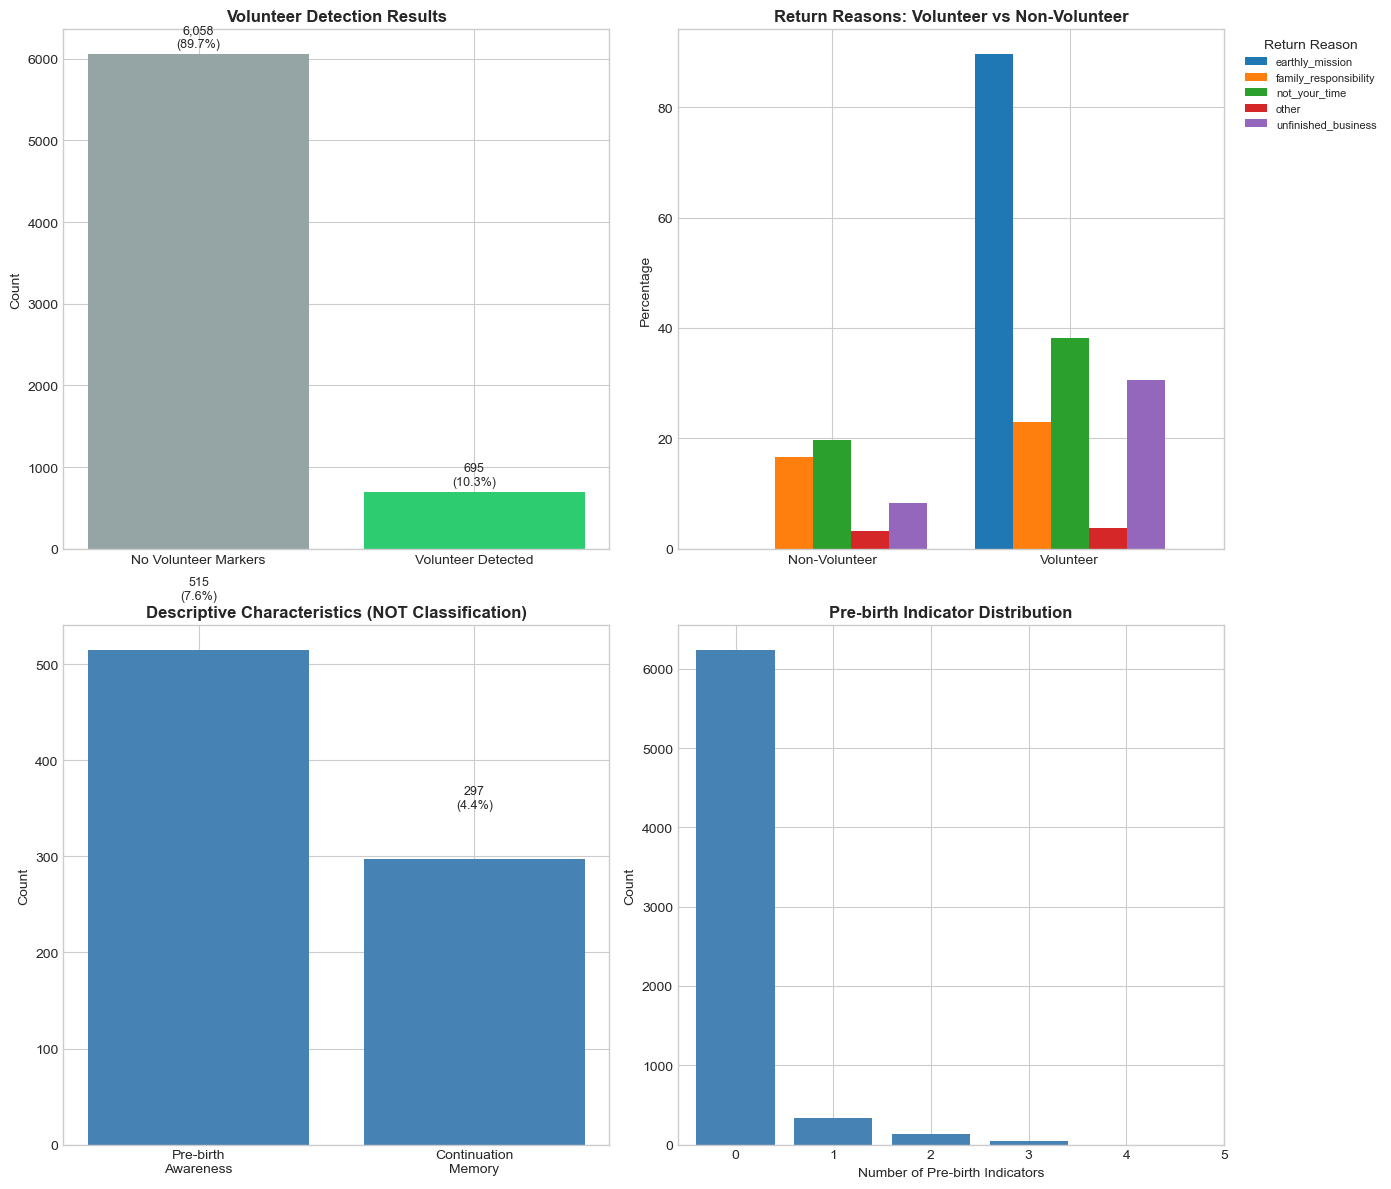


✓ Figure saved to ..\output\volunteer_detection_analysis.png


In [16]:
# =============================================================================
# PART VII: VISUALIZATIONS (Volunteer Detection + Descriptive Characteristics)
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Volunteer Detection (Binary)
ax1 = axes[0, 0]
vol_counts = df['volunteer_detected'].value_counts()
labels = ['No Volunteer Markers', 'Volunteer Detected']
colors = ['#95a5a6', '#2ecc71']
values = [vol_counts.get(False, 0), vol_counts.get(True, 0)]
bars = ax1.bar(labels, values, color=colors)
ax1.set_title('Volunteer Detection Results', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count')
for bar, count in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

# 2. Return Reasons: Volunteer vs Non-Volunteer
ax2 = axes[0, 1]
reason_flags = ['has_not_your_time', 'has_family_responsibility', 'has_unfinished_business', 
                'has_earthly_mission', 'has_other']
return_data = []
for detected, label in [(True, 'Volunteer'), (False, 'Non-Volunteer')]:
    subset = df[df['volunteer_detected'] == detected]
    if len(subset) > 0:
        for flag in reason_flags:
            if flag in df.columns:
                rate = subset[flag].mean() * 100
                return_data.append({'Group': label, 'Reason': flag.replace('has_', ''), 'Rate': rate})
return_df = pd.DataFrame(return_data)
if len(return_df) > 0:
    return_pivot = return_df.pivot(index='Group', columns='Reason', values='Rate').fillna(0)
    return_pivot.plot(kind='bar', ax=ax2, width=0.8)
    ax2.set_title('Return Reasons: Volunteer vs Non-Volunteer', fontsize=12, fontweight='bold')
    ax2.set_xlabel('')
    ax2.set_ylabel('Percentage')
    ax2.legend(title='Return Reason', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    ax2.tick_params(axis='x', rotation=0)

# 3. Descriptive Characteristics (NOT classification criteria)
ax3 = axes[1, 0]
characteristics = ['has_prebirth_awareness', 'has_continuation_memory']
char_labels = ['Pre-birth\nAwareness', 'Continuation\nMemory']
char_values = [df[c].sum() for c in characteristics]
char_pcts = [df[c].mean() * 100 for c in characteristics]
bars3 = ax3.bar(char_labels, char_values, color='steelblue')
ax3.set_title('Descriptive Characteristics (NOT Classification)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Count')
for bar, val, pct in zip(bars3, char_values, char_pcts):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

# 4. Pre-birth Indicator Count Distribution
ax4 = axes[1, 1]
indicator_dist = df['prebirth_indicator_count'].value_counts().sort_index()
ax4.bar(indicator_dist.index, indicator_dist.values, color='steelblue')
ax4.set_xlabel('Number of Pre-birth Indicators')
ax4.set_ylabel('Count')
ax4.set_title('Pre-birth Indicator Distribution', fontsize=12, fontweight='bold')
ax4.set_xticks([0, 1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'volunteer_detection_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Figure saved to {OUTPUT_DIR / 'volunteer_detection_analysis.png'}")

---

# Part VIII: Export & Summary

**Source**: `archive/volunteer_discriminant_analysis.ipynb` Part VIII

In [17]:
# =============================================================================
# PART VIII: EXPORT (Volunteer Detection + Descriptive Fields)
# =============================================================================

# Export columns - updated for corrected methodology
export_cols = ['title', 'dataset', 'source_file', 
               'volunteer_detected',  # Binary detection
               'has_volunteer_markers', 'prebirth_indicator_count',  # Measurement fields
               'has_prebirth_awareness', 'has_continuation_memory',  # Descriptive only
               'has_earthly_mission', 'has_family_responsibility', 'has_not_your_time',
               'return_agency', 'return_willingness',
               'mission_commissioned', 'volunteer_language',
               'premortal_existence_info', 'incarnation_choice', 'home_is_spiritual',
               'identity_pre_body', 'sense_of_belonging', 
               'past_life_memory', 'death_memory', 'intermission_memory']

# Ensure all columns exist
export_cols = [c for c in export_cols if c in df.columns]

df[export_cols].to_csv(OUTPUT_DIR / 'volunteer_detection.csv', index=False)
print(f"✓ Exported {len(df):,} cases to {OUTPUT_DIR / 'volunteer_detection.csv'}")

# Export by detection status
vol_cases = df[df['volunteer_detected']][export_cols]
vol_cases.to_csv(OUTPUT_DIR / 'volunteer_detected_cases.csv', index=False)
print(f"✓ Exported {len(vol_cases):,} Volunteer-detected cases to {OUTPUT_DIR / 'volunteer_detected_cases.csv'}")

non_vol_cases = df[~df['volunteer_detected']][export_cols]
non_vol_cases.to_csv(OUTPUT_DIR / 'non_volunteer_cases.csv', index=False)
print(f"✓ Exported {len(non_vol_cases):,} non-Volunteer cases to {OUTPUT_DIR / 'non_volunteer_cases.csv'}")

✓ Exported 6,753 cases to ..\output\volunteer_detection.csv
✓ Exported 695 Volunteer-detected cases to ..\output\volunteer_detected_cases.csv
✓ Exported 6,058 non-Volunteer cases to ..\output\non_volunteer_cases.csv


In [18]:
# =============================================================================
# FINAL SUMMARY (CORRECTED METHODOLOGY)
# =============================================================================

print("="*80)
print("VOLUNTEER DETECTION ANALYSIS SUMMARY")
print("="*80)

print(f"\n📊 DATASET")
print(f"   Total records analyzed: {len(df):,}")
for dataset in df['dataset'].unique():
    count = (df['dataset'] == dataset).sum()
    print(f"   - {dataset}: {count:,}")

print(f"\n🎯 VOLUNTEER DETECTION (BINARY)")
vol_count = df['volunteer_detected'].sum()
non_vol_count = (~df['volunteer_detected']).sum()
print(f"   Volunteer markers detected: {vol_count:,} ({vol_count/len(df)*100:.1f}%)")
print(f"   No volunteer markers: {non_vol_count:,} ({non_vol_count/len(df)*100:.1f}%)")

print(f"\n📈 VOLUNTEER PROFILE (Detected Cases)")
vol_df = df[df['volunteer_detected']]
if len(vol_df) > 0:
    vol_mission = vol_df['mission_commissioned'].isin(['yes_explicit', 'implied']).mean() * 100
    vol_earthly = vol_df['has_earthly_mission'].mean() * 100
    # volunteer_language is categorical, check for explicit/implied values
    vol_language = vol_df['volunteer_language'].isin(['yes_explicit', 'implied']).mean() * 100
    print(f"   Mission commission rate: {vol_mission:.1f}%")
    print(f"   Earthly mission return: {vol_earthly:.1f}%")
    print(f"   Volunteer language present: {vol_language:.1f}%")

print(f"\n🏠 HOME IDENTIFICATION")
print(f"   Records identifying spiritual realm as home: {df['home_is_spiritual'].sum():,} ({df['home_is_spiritual'].mean()*100:.1f}%)")
if len(vol_df) > 0:
    vol_home = vol_df['home_is_spiritual'].mean() * 100
    non_vol_df = df[~df['volunteer_detected']]
    non_vol_home = non_vol_df['home_is_spiritual'].mean() * 100
    print(f"   Volunteer-detected: {vol_home:.1f}% | Non-Volunteer: {non_vol_home:.1f}%")

print(f"\n📝 DESCRIPTIVE CHARACTERISTICS (NOT Classification)")
print(f"   Pre-birth awareness: {df['has_prebirth_awareness'].sum():,} ({df['has_prebirth_awareness'].mean()*100:.1f}%)")
print(f"   Continuation memory: {df['has_continuation_memory'].sum():,} ({df['has_continuation_memory'].mean()*100:.1f}%)")
print(f"   → These are DESCRIPTIVE only. Pre-birth awareness appears in any NDE.")
print(f"   → Continuation memory could be spiritual pre-existence OR prior earth life.")

print(f"\n🔄 RETURN DECISION ANALYSIS")
print(f"   Return Agency Distribution:")
for agency in ['self', 'external_being', 'mutual', 'involuntary']:
    count = (df['return_agency'] == agency).sum()
    if count > 0:
        pct = count / len(df) * 100
        print(f"     {agency}: {count:,} ({pct:.1f}%)")

print(f"\n💾 EXPORTS")
print(f"   - volunteer_detection.csv ({len(df):,} cases)")
print(f"   - volunteer_detected_cases.csv ({vol_count:,} cases)")
print(f"   - non_volunteer_cases.csv ({non_vol_count:,} cases)")
print(f"   - volunteer_detection_analysis.png")

print(f"\n" + "="*80)
print("WHAT THIS ANALYSIS TELLS US")
print("="*80)
print(f"""
✅ WHAT WE CAN MEASURE:
   • Volunteer markers (mission language, earthly mission return, commissioned missions)
   • Pre-birth awareness (experiencer recalled pre-existence DURING the NDE)
   • Continuation memory (any prior existence memory - source ambiguous)
   • Return patterns (agency, willingness)

❌ WHAT WE CANNOT MEASURE FROM NDE DATA:
   • Soul path classification (Volunteer vs Normative vs Restorative)
   • First vs. returning incarnation
   • Ohkado "Reverse Cases" (different methodology - CHILDREN, not NDE)
   • Restorative path (requires DOPS: verified earth details, birthmarks, 70%+ violent death)

⚠️  METHODOLOGICAL NOTES:
   • Pre-birth awareness in NDE is NOT "Ohkado classification"
   • Ohkado studied CHILDREN with spontaneous pre-birth recall WITHOUT past-life claims
   • Our NDE data is ADULTS reporting pre-birth awareness DURING an NDE
   • The NDE itself may trigger pre-birth awareness in ANY experiencer
   • Continuation memory simply indicates prior existence - nothing more

🎯 BOTTOM LINE:
   We detect MARKERS, not paths. We measure what we can measure. Nothing more.
""")

VOLUNTEER DETECTION ANALYSIS SUMMARY

📊 DATASET
   Total records analyzed: 6,753
   - iands: 1,089
   - nderf: 5,664

🎯 VOLUNTEER DETECTION (BINARY)
   Volunteer markers detected: 695 (10.3%)
   No volunteer markers: 6,058 (89.7%)

📈 VOLUNTEER PROFILE (Detected Cases)
   Mission commission rate: 92.7%
   Earthly mission return: 89.6%
   Volunteer language present: 7.6%

🏠 HOME IDENTIFICATION
   Records identifying spiritual realm as home: 1,159 (17.2%)
   Volunteer-detected: 41.4% | Non-Volunteer: 14.4%

📝 DESCRIPTIVE CHARACTERISTICS (NOT Classification)
   Pre-birth awareness: 515 (7.6%)
   Continuation memory: 297 (4.4%)
   → These are DESCRIPTIVE only. Pre-birth awareness appears in any NDE.
   → Continuation memory could be spiritual pre-existence OR prior earth life.

🔄 RETURN DECISION ANALYSIS
   Return Agency Distribution:
     self: 1,124 (16.6%)
     external_being: 1,931 (28.6%)
     mutual: 305 (4.5%)
     involuntary: 1,422 (21.1%)

💾 EXPORTS
   - volunteer_detection.csv (6